In [8]:
import matplotlib.pyplot as plt

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr

def read_sbe_cnv_to_xarray(file):
    file = Path(file)

    header = []
    data_lines = []
    in_data = False

    with open(file, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if line == "*END*":
                in_data = True
                continue

            if in_data:
                if line:
                    data_lines.append(line)
            else:
                header.append(line)

    # -----------------------
    # Parse column names
    # -----------------------
    names = {}
    for line in header:
        m = re.match(r"# name\s+(\d+)\s+=\s+([^:]+):", line)
        if m:
            idx = int(m.group(1))
            varname = m.group(2).strip()
            names[idx] = varname

    columns = [names[i] for i in sorted(names)]

    # -----------------------
    # Parse metadata
    # -----------------------
    attrs = {}

    for line in header:
        if line.startswith("* NMEA Latitude"):
            attrs["NMEA Latitude"] = line.split("=")[1].strip()
        elif line.startswith("* NMEA Longitude"):
            attrs["NMEA Longitude"] = line.split("=")[1].strip()
        elif line.startswith("# start_time"):
            attrs["start_time"] = line.split("=")[1].split("[")[0].strip()
        elif line.startswith("# bad_flag"):
            attrs["bad_flag"] = float(line.split("=")[1].strip())

    # -----------------------
    # Read numeric data
    # -----------------------
    from io import StringIO

    df = pd.read_csv(
        StringIO("\n".join(data_lines)),
        sep=r"\s+",
        names=columns,
        engine="python"
    )

    # Replace bad values
    if "bad_flag" in attrs:
        df = df.replace(attrs["bad_flag"], np.nan)

    # -----------------------
    # Rename useful variables
    # -----------------------
    rename = {
        "prDM": "press",
        "depSM": "depth",
        "latitude": "lat",
        "longitude": "lon",
        "t090C": "temp",
        "t190C": "temp2",
        "sal00": "sal",
        "potemp090C": "theta",
        "sigma-t00": "sigma_t",
        "sbeox0ML/L": "O2",
        "timeS": "time_elapsed",
    }

    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Sort by pressure, just in case
    df = df.sort_values("press")

    # -----------------------
    # Make xarray Dataset
    # -----------------------
    ds = df.set_index("press").to_xarray()

    # Make lat/lon scalar coordinates if they are basically constant
    if "lat" in ds:
        lat_mean = float(ds["lat"].mean())
        ds = ds.drop_vars("lat")
        ds = ds.assign_coords(lat=lat_mean)

    if "lon" in ds:
        lon_mean = float(ds["lon"].mean())
        ds = ds.drop_vars("lon")
        ds = ds.assign_coords(lon=lon_mean)

    if "start_time" in attrs:
        ds = ds.assign_coords(time=pd.to_datetime(attrs["start_time"]))

    ds.attrs.update(attrs)

    return ds

In [12]:
from pathlib import Path

folder = Path("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged")

In [13]:
sorted(folder.glob("*.cnv"))

[WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD01.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD02.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD03.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD04.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD05.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Arao

In [5]:
ds = read_sbe_cnv_to_xarray(file="//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD01.cnv")

In [6]:
ds

<xarray.Dataset> Size: 122kB
Dimensions:       (press: 802)
Coordinates:
  * press         (press) float64 6kB 5.0 6.0 7.0 8.0 ... 804.0 805.0 806.0
    lat           float64 8B -74.89
    lon           float64 8B 165.1
    time          datetime64[ns] 8B 2018-03-04T09:44:26
Data variables: (12/18)
    c0S/m         (press) float64 6kB 2.742 2.754 2.768 ... 2.768 2.768 2.768
    c1S/m         (press) float64 6kB 2.703 2.695 2.688 ... 2.767 2.767 2.767
    altM          (press) float64 6kB 98.71 98.71 98.71 ... 45.96 45.87 45.8
    flECO-AFL     (press) float64 6kB 2.003 1.902 2.01 ... 0.0198 0.0198 0.0198
    O2            (press) float64 6kB 6.106 6.144 6.234 5.856 ... nan nan nan
    par           (press) float64 6kB 0.4505 0.3622 0.3108 ... 0.1016 0.1016
    ...            ...
    sal           (press) float64 6kB 34.98 35.13 35.23 ... 34.85 34.85 34.85
    theta         (press) float64 6kB -1.877 -1.868 -1.784 ... -1.921 -1.921
    sigma_t       (press) float64 6kB 28.16 28.29 28.37 ... 28.06 28.06 28.06
    svCM          (press) float64 6kB 1.44e+03 1.441e+03 ... 1.453e+03 1.453e+03
    oxsatML/L     (press) float64 6kB 8.465 8.454 8.429 ... 8.478 8.478 8.478
    flag          (press) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    NMEA Latitude:   74 53.57 S
    NMEA Longitude:  165 04.85 E
    start_time:      Mar 04 2018 09:44:26
    bad_flag:        -9.99e-29

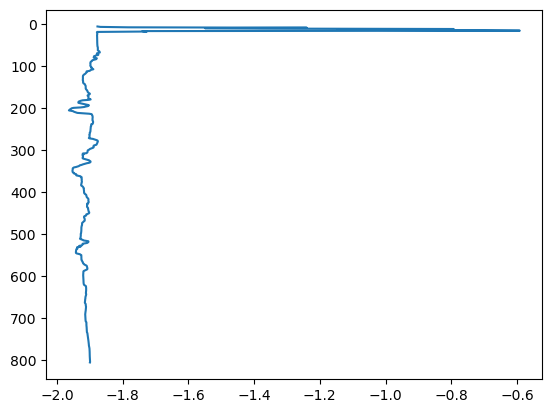

In [10]:
fig = plt.figure()
plt.plot(ds.temp,ds.press)
plt.gca().invert_yaxis()

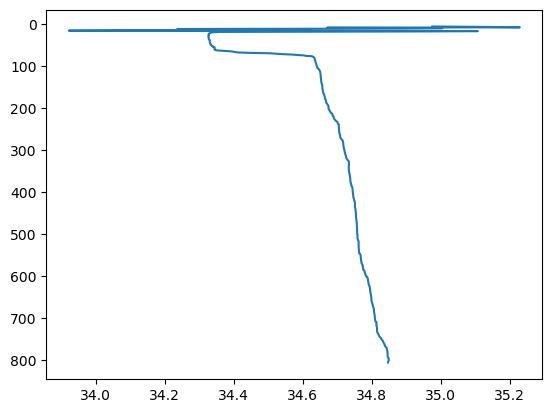

In [11]:
fig = plt.figure()
plt.plot(ds.sal,ds.press)
plt.gca().invert_yaxis()

In [14]:
# load and format all files 
casts = {}

for i, file in enumerate(sorted(folder.glob("*.cnv")), start=1):
    
    ds = read_sbe_cnv_to_xarray(file)
    
    ds.attrs["source_file"] = file.name
    ds = ds.assign_coords(station=i)
    
    casts[i] = ds

In [15]:
casts

{1: <xarray.Dataset> Size: 122kB
 Dimensions:       (press: 802)
 Coordinates:
   * press         (press) float64 6kB 5.0 6.0 7.0 8.0 ... 804.0 805.0 806.0
     lat           float64 8B -74.89
     lon           float64 8B 165.1
     time          datetime64[ns] 8B 2018-03-04T09:44:26
     station       int64 8B 1
 Data variables: (12/18)
     c0S/m         (press) float64 6kB 2.742 2.754 2.768 ... 2.768 2.768 2.768
     c1S/m         (press) float64 6kB 2.703 2.695 2.688 ... 2.767 2.767 2.767
     altM          (press) float64 6kB 98.71 98.71 98.71 ... 45.96 45.87 45.8
     flECO-AFL     (press) float64 6kB 2.003 1.902 2.01 ... 0.0198 0.0198 0.0198
     O2            (press) float64 6kB 6.106 6.144 6.234 5.856 ... nan nan nan
     par           (press) float64 6kB 0.4505 0.3622 0.3108 ... 0.1016 0.1016
     ...            ...
     sal           (press) float64 6kB 34.98 35.13 35.23 ... 34.85 34.85 34.85
     theta         (press) float64 6kB -1.877 -1.868 -1.784 ... -1.921 -1.921
    

In [34]:
cast = casts[30]

Text(0.5, 0, 'Sal')

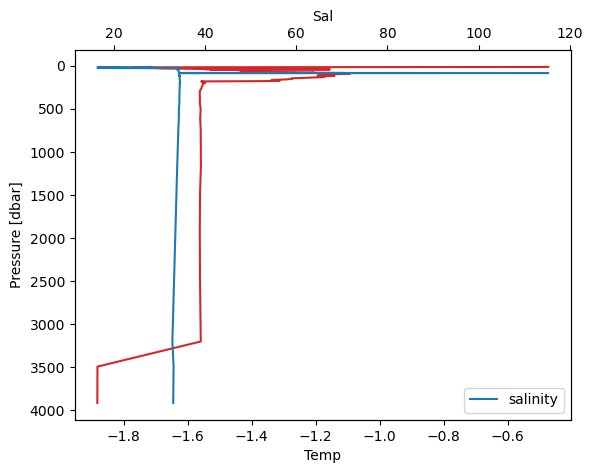

In [35]:
fig, ax = plt.subplots()
ax.plot(cast.temp,cast.press,color='tab:red',label='Temp')
ax.invert_yaxis()
ax1 = ax.twiny()
ax1.plot(cast.sal,cast.press,color='tab:blue',label='salinity')
plt.legend()
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Temp')
ax1.set_xlabel('Sal')